In [ ]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


In [1]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

--- Dataset Dimensionality Information ---
Total Data Shape: (480, 448, 77, 17)
Navigation Axes (Scan Grid): (77, 17)
Signal Axes (Diffraction Pattern): (480, 448)
Verification: SUCCESS (4D dataset detected: 2 Navigation + 2 Signal).


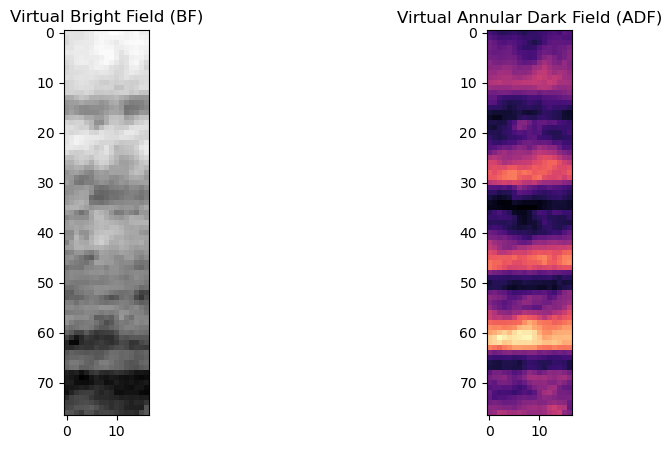

In [27]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

# 1. Read data
pf = r"C:\Users\ccy82\Documents\465-HW2\Si-SiGe.dm4"
dataset = py4DSTEM.import_file(pf)


# 2. Define function to verify axes (Task 1 requirement)
def check_axes(dc):
    """
    印出並驗證 Navigation (掃描軸) 與 Signal (衍射軸)
    """
    print("--- Dataset Dimensionality Information ---")
    
    # Get total dimensions
    total_shape = dc.data.shape
    print(f"Total Data Shape: {total_shape}")
    
    # In this specific 4D-STEM dataset:
    # First two dimensions are Signal (Qy, Qx)
    # Last two dimensions are Navigation (Ny, Nx)
    nav_shape = total_shape[2:]
    sig_shape = total_shape[:2]
    
    print(f"Navigation Axes (Scan Grid): {nav_shape}")
    print(f"Signal Axes (Diffraction Pattern): {sig_shape}")
    
    if len(total_shape) == 4:
        print("Verification: SUCCESS (4D dataset detected: 2 Navigation + 2 Signal).")
    else:
        print(f"Verification: WARNING (Expected 4 dimensions, found {len(total_shape)}).")
    
    return nav_shape, sig_shape

# Execute verification
nav_shape, sig_shape = check_axes(dataset)

# 3. Virtual Detector Framework Class (Check List requirement)
class VirtualDetectorManager:
    def __init__(self, datacube):
        """
        Setup and Virtual Detector Framework
        """
        self.dc = datacube
        # 直接從數據矩陣獲取大小
        self.qy_size = datacube.data.shape[0]
        self.qx_size = datacube.data.shape[1]
        
        # 預設中心
        self.center_y = self.qy_size // 2
        self.center_x = self.qx_size // 2
        
        # 倒易空間最大半徑
        self.max_fov = min(self.qy_size, self.qx_size) // 2

    def _check_bounds(self, radii):
        """
        Check List: Ensure detector radii lie within the FOV.
        """
        for r in radii:
            if r < 0 or r > self.max_fov:
                print(f"⚠️ Warning: Radius {r} is outside FOV ({self.max_fov})")

    def create_mask(self, mode='BF', inner_r=0, outer_r=10):
        """
        Check List: Define virtual detector geometries.
        """
        self._check_bounds([inner_r, outer_r])
        
        # Create coordinate grid
        y, x = np.ogrid[:self.qy_size, :self.qx_size]
        dist = np.sqrt((y - self.center_y)**2 + (x - self.center_x)**2)

        if mode == 'BF':
            mask = dist <= outer_r
        elif mode == 'ADF':
            mask = (dist >= inner_r) & (dist <= outer_r)
        else:
            mask = np.ones((self.qy_size, self.qx_size))
        
            
        return mask

    def apply_detector(self, mask):
        """
        Check List: Apply detector and return virtual image on the scan grid.
        """
        # Broadcast 2D mask (Qy, Qx) to 4D (Qy, Qx, 1, 1) to match data shape
        # This allows element-wise multiplication across the scan grid
        mask_4d = mask[:, :, None, None]
        virtual_image = np.sum(self.dc.data* mask_4d, axis=(0, 1))
        return virtual_image

# --- Visualize ---

# Initialize manager
vd_tool = VirtualDetectorManager(dataset)

# 1. Create Virtual Bright Field (BF) Image
bf_mask = vd_tool.create_mask(mode='BF', outer_r=12)
bf_image = vd_tool.apply_detector(bf_mask)

# 2. Create Virtual Annular Dark Field (ADF) Image
adf_mask = vd_tool.create_mask(mode='ADF', inner_r=30, outer_r=60)
adf_image = vd_tool.apply_detector(adf_mask)

# 3. Plotting results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(bf_image, cmap='gray')
ax[0].set_title("Virtual Bright Field (BF)")
ax[1].imshow(adf_image, cmap='magma')
ax[1].set_title("Virtual Annular Dark Field (ADF)")
plt.savefig("4DSTEM_Real_Space_Images.png", dpi=300, bbox_inches='tight')
plt.show()

Navigation (Scan): (77, 17)
Signal (Diffraction): (480, 448)


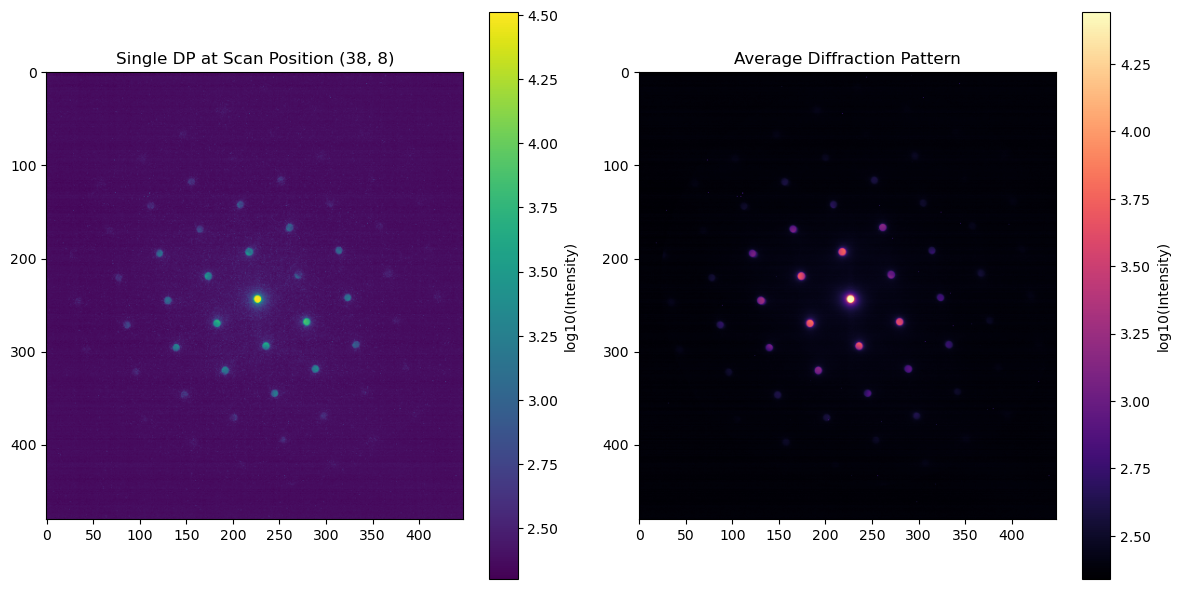

In [3]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt
# 1. Read data
pf = r"C:\Users\ccy82\Documents\465-HW2\Si-SiGe.dm4"
dataset = py4DSTEM.import_file(pf)
corrected_data = np.transpose(dataset.data,(2,3,0,1))
dataset.data = corrected_data

# 2. Verify axes (Task 1)
def check_axes(dc):
    total_shape = dc.data.shape
    nav_shape = total_shape[:2]
    sig_shape = total_shape[2:]
    print(f"Navigation (Scan): {nav_shape}")
    print(f"Signal (Diffraction): {sig_shape}")
    return nav_shape, sig_shape

nav_shape, sig_shape = check_axes(dataset)

# --- 3. Display Diffraction Patterns (DP) ---

# Select coordinates at the center of the scan grid (Ny/2, Nx/2)
ry, rx = nav_shape[0] // 2, nav_shape[1] // 2

# Extract a 2D diffraction pattern from that specific scan point
single_dp = dataset.data[ry, rx, :, :]

# Calculate the average diffraction pattern of the entire dataset
# (Useful for checking overall alignment and signal quality)
# Note: This step may take some time for very large datasets.
avg_dp = np.mean(dataset.data, axis=(0, 1))

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# 顯示單點 DP
# 使用 log 尺度（加 1 防止 log(0)）能更清楚看到弱的衍射斑點
im1 = ax[0].imshow(np.log10(single_dp + 1), cmap='viridis')
ax[0].set_title(f"Single DP at Scan Position ({ry}, {rx})")
plt.colorbar(im1, ax=ax[0], label='log10(Intensity)')

# 顯示平均 DP
im2 = ax[1].imshow(np.log10(avg_dp + 1), cmap='magma')
ax[1].set_title("Average Diffraction Pattern")
plt.colorbar(im2, ax=ax[1], label='log10(Intensity)')

plt.tight_layout()
plt.savefig("4DSTEM_Virtual_Images.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

Using calibration: 1.0 pixels/pixel


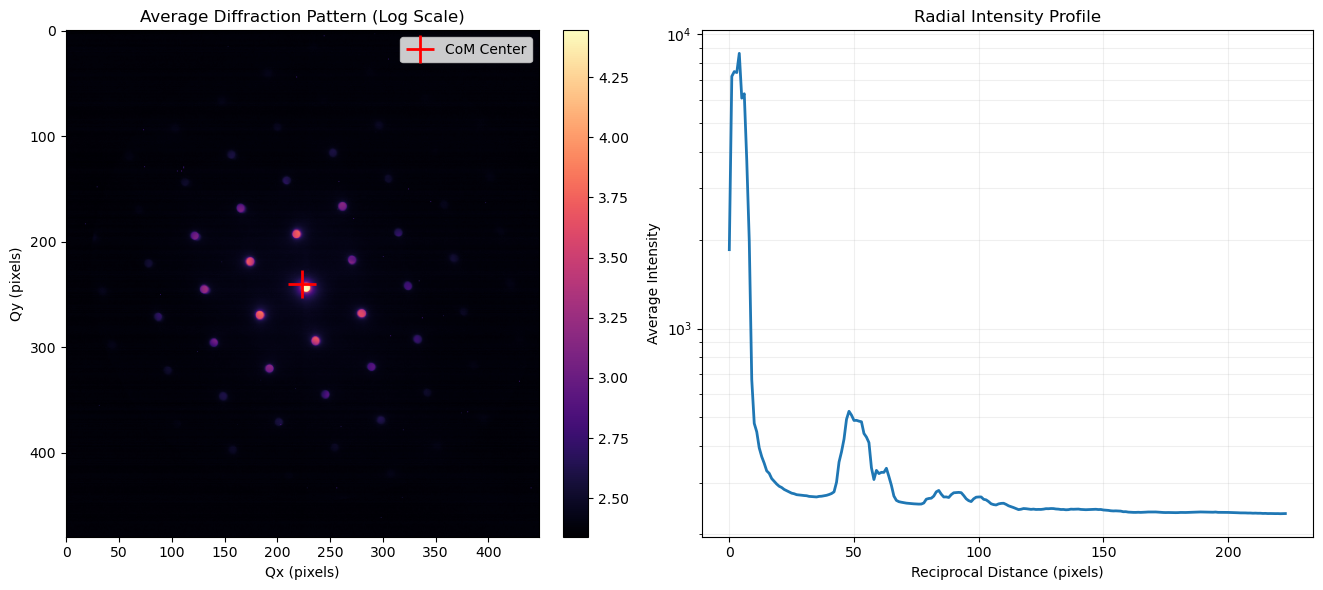

In [4]:
# 1. Extract Average Diffraction Pattern and Calculate Center of Mass (CoM)
# Using dataset.data to compute the mean across all scan positions (Ny, Nx)
avg_dp = np.mean(dataset.data, axis=(0, 1))
qy, qx = avg_dp.shape
yy, xx = np.indices((qy, qx))

total_int = np.sum(avg_dp)
com_y = np.sum(avg_dp * yy) / (total_int + 1e-9)
com_x = np.sum(avg_dp * xx) / (total_int + 1e-9)

# 2. Define Radial Profile Function
def get_radial_profile(dp, center_y, center_x, n_bins=None):
    y, x = np.indices(dp.shape)
    r = np.sqrt((y - center_y)**2 + (x - center_x)**2)
    
    if n_bins is None:
        n_bins = int(np.min(dp.shape) // 2)
    
    r_int = r.astype(int)
    # Ensure indices do not exceed the bin range
    mask = r_int < n_bins
    tbin = np.bincount(r_int[mask], dp[mask])
    nr = np.bincount(r_int[mask])
    profile = tbin / (nr + 1e-9)
    return profile

# Execute the radial profile calculation
radial_prof = get_radial_profile(avg_dp, com_y, com_x)

# 3. Retrieve Calibration Values (Handling potential AttributeErrors)
# Attempt to fetch from dataset attributes, otherwise provide fallback defaults
try:
    q_pixel_size = dataset.calibration.Q_pixel_size
    q_units = dataset.calibration.Q_units
except AttributeError:
    q_pixel_size = 1.0
    q_units = "pixels"

print(f"Using calibration: {q_pixel_size} {q_units}/pixel")

# 4. Create X-axis coordinates for plotting
q_axis = np.arange(len(radial_prof)) * q_pixel_size

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Average DP with CoM Marker
# Log10 scale is used to make higher-order diffraction spots visible
im1 = ax1.imshow(np.log10(avg_dp + 1), cmap='magma', origin='upper')
ax1.plot(com_x, com_y, 'r+', markersize=20, markeredgewidth=2, label='CoM Center')
ax1.set_title("Average Diffraction Pattern (Log Scale)")
ax1.set_xlabel("Qx (pixels)")
ax1.set_ylabel("Qy (pixels)")
ax1.legend()
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Right Plot: Radial Intensity Profile
ax2.plot(q_axis, radial_prof, linewidth=2, color='tab:blue')
ax2.set_title("Radial Intensity Profile")
ax2.set_xlabel(f"Reciprocal Distance ({q_units})")
ax2.set_ylabel("Average Intensity")
ax2.set_yscale('log')  # Diffraction intensity often spans several orders of magnitude
ax2.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig("4DSTEM_Diffraction_Pattern_and_Radical_Intensity_Profile.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

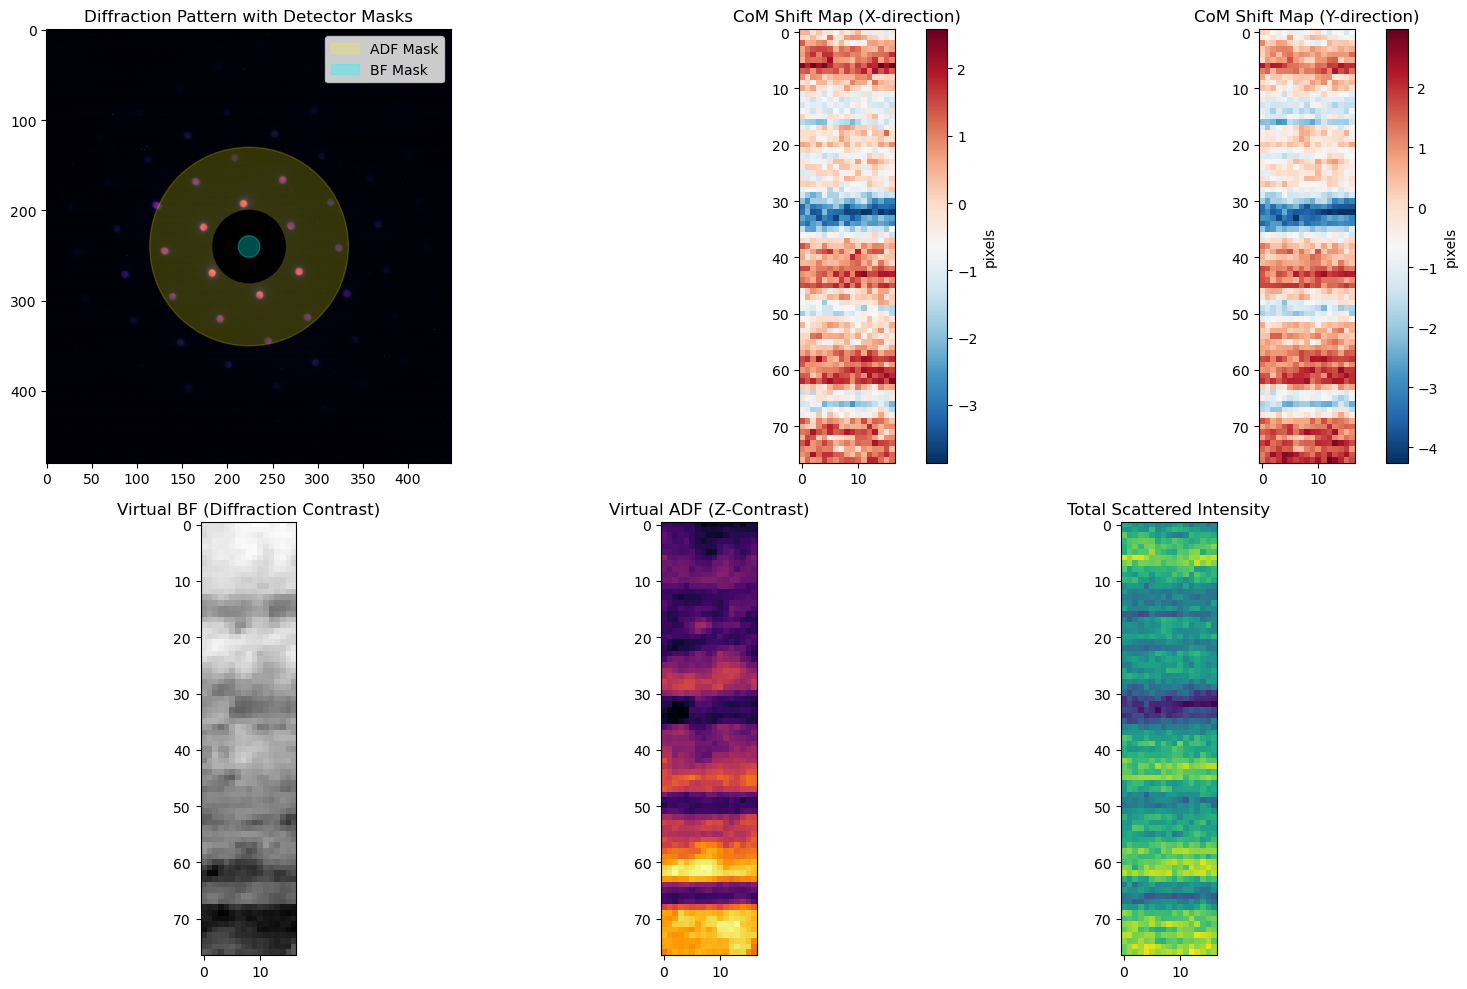

In [5]:
import matplotlib.patches as patches

# 1. Compute X/Y Shifts and Total Intensity (Satisfies Task 2/3 Check List)
def compute_shfits_and_stats(dc):
    data = dc.data
    qy, qx = data.shape[2:]
    yy, xx = np.indices((qy, qx))

   # Calculate total intensity per DP (adding small epsilon to avoid division by zero)
    sum_data = np.sum(data, axis=(2, 3)) + 1e-9
    # Calculate the Center of Mass (CoM) for each scanning point (represents beam shift)
    shift_y = np.sum(data * yy, axis=(2, 3)) / sum_data
    shift_x = np.sum(data * xx, axis=(2, 3)) / sum_data
    
    # Subtract the global mean to obtain the relative shift (local variations)
    shift_y -= np.mean(shift_y)
    shift_x -= np.mean(shift_x)
    
    return shift_y, shift_x, sum_data

# Execute shift calculation
shift_y, shift_x, total_int = compute_shfits_and_stats(dataset)

# 2. Virtual Detector Configuration
bf_radius = 12
adf_inner = 40
adf_outer = 110

# --- 3. Comprehensive Visualization ---
fig = plt.figure(figsize=(16, 10))

# A. Average Diffraction Pattern + Visualization of Detector Masks
ax1 = fig.add_subplot(2, 3, 1)
avg_dp = np.mean(dataset.data, axis=(0, 1))
cy, cx = avg_dp.shape[0]//2, avg_dp.shape[1]//2
ax1.imshow(np.log10(avg_dp + 1), cmap='magma')

# Draw BF Range (Cyan Circle)
circle_bf = patches.Circle((cx, cy), bf_radius, color='cyan', fill=True, alpha=0.3, label='BF Mask')
# Draw ADF Range (Yellow Annulus)
circle_adf_out = patches.Circle((cx, cy), adf_outer, color='yellow', fill=True, alpha=0.2, label='ADF Mask')
circle_adf_in = patches.Circle((cx, cy), adf_inner, color='black', fill=True, alpha=1.0) # Mask the center for the ADF display
ax1.add_patch(circle_adf_out)
ax1.add_patch(circle_adf_in)
ax1.add_patch(circle_bf)

ax1.set_title("Diffraction Pattern with Detector Masks")
ax1.legend(loc='upper right')

# B. X-Shift Map (Reflects horizontal beam deflection)
ax2 = fig.add_subplot(2, 3, 2)
im2 = ax2.imshow(shift_x, cmap='RdBu_r')
ax2.set_title("CoM Shift Map (X-direction)")
plt.colorbar(im2, ax=ax2, label='pixels')

# C. Y-Shift Map (Reflects vertical beam deflection)
ax3 = fig.add_subplot(2, 3, 3)
im3 = ax3.imshow(shift_y, cmap='RdBu_r')
ax3.set_title("CoM Shift Map (Y-direction)")
plt.colorbar(im3, ax=ax3, label='pixels')

# D. Virtual BF Image (Reconstruction result)
ax4 = fig.add_subplot(2, 3, 4)
# Apply BF mask manually
y_idx, x_idx = np.indices(avg_dp.shape)
bf_mask = np.sqrt((y_idx-cy)**2 + (x_idx-cx)**2) <= bf_radius
bf_res = np.sum(dataset.data * bf_mask, axis=(2, 3))
ax4.imshow(bf_res, cmap='gray')
ax4.set_title("Virtual BF (Diffraction Contrast)")

# E. Virtual ADF Image (Reconstruction result)
ax5 = fig.add_subplot(2, 3, 5)
# Apply ADF mask manually
adf_mask = (np.sqrt((y_idx-cy)**2 + (x_idx-cx)**2) >= adf_inner) & \
           (np.sqrt((y_idx-cy)**2 + (x_idx-cx)**2) <= adf_outer)
adf_res = np.sum(dataset.data * adf_mask, axis=(2, 3))
ax5.imshow(adf_res, cmap='inferno')
ax5.set_title("Virtual ADF (Z-Contrast)")

# F. Total Scattered Intensity (Data Statistics)
ax6 = fig.add_subplot(2, 3, 6)
ax6.imshow(total_int, cmap='viridis')
ax6.set_title("Total Scattered Intensity")

plt.tight_layout()
plt.savefig("4DSTEM_Diffraction_Pattern_Mask_and_CoM_Analysis.png", dpi=300, bbox_inches='tight')
plt.show()

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

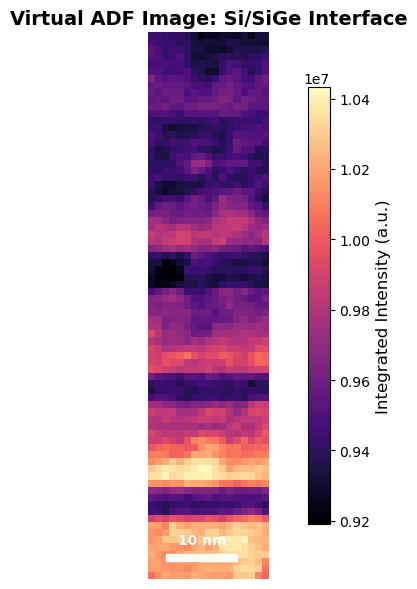

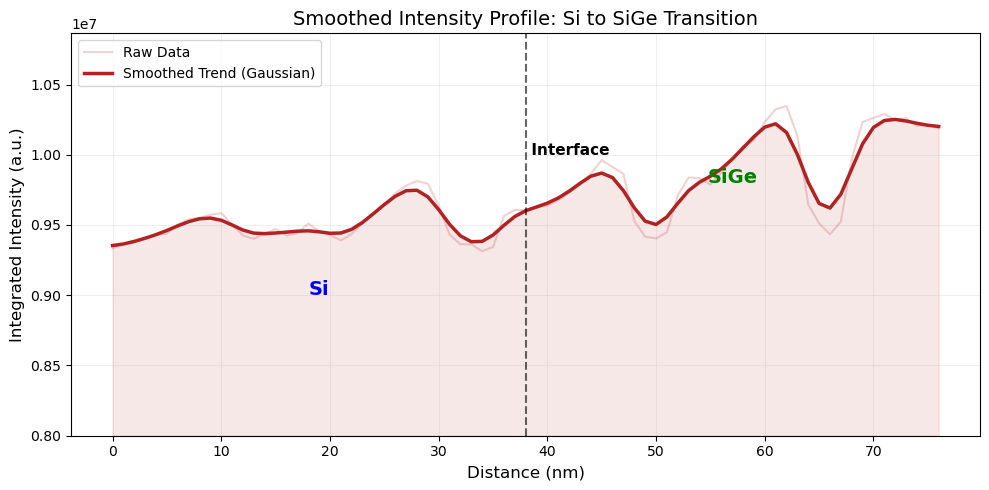

Launching 4D-STEM browser...
Browser launch skipped: module 'py4DSTEM.visualize' has no attribute 'show_image'


In [6]:

from matplotlib.patches import Rectangle
from scipy.ndimage import gaussian_filter1d  # 必須加入這一行來修正 NameError

# 1. Ensure physical unit values (Handling potential Calibration attribute errors)
# Uses previously defined variables; falls back to 1.0 if missing
try:
    r_pixel_size = scan_step_size 
except NameError:
    r_pixel_size = 1.0  # fallback
    print("Warning: scan_step_size not found, using 1.0 nm as fallback.")

# 2. Create high-quality ADF Image
fig, ax = plt.subplots(figsize=(8, 6))

# Use perceptually uniform colormap 'magma'
# adf_res is the image calculated previously in Task 3
im = ax.imshow(adf_res, cmap='magma', origin='upper')
ax.set_title("Virtual ADF Image: Si/SiGe Interface", fontsize=14, fontweight='bold')
ax.axis('off') 

# --- Integrate Scale Bar Code ---
scale_bar_length = 10 
scale_bar_pixels = scale_bar_length / r_pixel_size

# Ensure the scale bar does not exceed image dimensions
if scale_bar_pixels < adf_res.shape[1] - 5:
    # Positioned at bottom-left (2, H-4)
    bar_x, bar_y = 2, adf_res.shape[0] - 4
    scale_bar = Rectangle((bar_x, bar_y), scale_bar_pixels, 1, fill=True, color='white', linewidth=1)
    ax.add_patch(scale_bar)
    ax.text(bar_x + scale_bar_pixels/2, bar_y - 1, f'{scale_bar_length} nm', 
            ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')

# Add Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Integrated Intensity (a.u.)', fontsize=12)

plt.tight_layout()
plt.savefig('virtual_adf_figure_sisige.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Interface Intensity Profile Analysis (Optimized Y-axis and Labels) ---

# 1. Prepare data
# Assumes adf_res and r_pixel_size are already defined
raw_profile = np.mean(adf_res, axis=1) 
dist_axis = np.arange(len(raw_profile)) * r_pixel_size
interface_idx = len(dist_axis) // 2

# 2. Perform smoothing (Fixes NameError)
# Sigma controls smoothing; 1.5 is typically ideal to balance noise vs. resolution
smoothed_profile = gaussian_filter1d(raw_profile, sigma=1.5)

# 3. Plotting
plt.figure(figsize=(10, 5))

# Plot raw data (Lighter color to show actual scan fluctuations/noise)
plt.plot(dist_axis, raw_profile, color='firebrick', alpha=0.2, label='Raw Data')

# Plot smoothed trend line (Darker color to highlight the Z-contrast step)
plt.plot(dist_axis, smoothed_profile, color='firebrick', lw=2.5, label='Smoothed Trend (Gaussian)')

# Fill area to provide visual weight to the chart
plt.fill_between(dist_axis, smoothed_profile, 0.8e7, color='firebrick', alpha=0.1)

# Set Y-axis starting from 0.8e7 to emphasize the interface intensity jump
plt.ylim(0.8e7, np.max(raw_profile) * 1.05) 

# Mark the interface position (Vertical dashed line)
plt.axvline(x=dist_axis[interface_idx], color='black', linestyle='--', alpha=0.6)
plt.text(dist_axis[interface_idx], plt.ylim()[1]*0.92, ' Interface', fontsize=11, fontweight='bold')

# Label material regions (Si has lower intensity, SiGe has higher intensity)
plt.text(dist_axis[interface_idx]*0.5, 0.9e7, 'Si', 
         fontsize=14, fontweight='bold', ha='center', color='blue')
plt.text(dist_axis[interface_idx] + (dist_axis[-1] - dist_axis[interface_idx])*0.5, 
         0.98e7, 'SiGe', 
         fontsize=14, fontweight='bold', ha='center', color='green')

plt.title("Smoothed Intensity Profile: Si to SiGe Transition", fontsize=14)
plt.xlabel("Distance (nm)", fontsize=12)
plt.ylabel("Integrated Intensity (a.u.)", fontsize=12)
plt.grid(alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig("4DSTEM_Interface_ADF_Image_and_Intensity_Profile.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Launch Interactive Browser (Task 4 Requirement) ---
# Utilizing the built-in py4DSTEM visualization tool
try:
    print("Launching 4D-STEM browser...")
    py4DSTEM.visualize.show_image(dataset.data)
except Exception as e:
    print(f"Browser launch skipped: {e}")

## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [ ]:
# Your code here